# Отток клиентов

Beta Bank customers are leaving: little by little, chipping away every month. The bankers figured out it’s cheaper to save the existing customers than to attract new ones.

We need to predict whether the customer will leave the bank soon. You have the data on clients’ past behavior and termination of contracts with the bank. 

Build a model with the maximum possible *F1* score. To pass the project, you need an *F1* score of at least 0.59. Check the *F1* for the test set.

Additionally, measure the *AUC-ROC* metric and compare it with the *F1*.

Data source: [https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling](https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling)

# 1. Data preparation

### Data research

In [1]:
%matplotlib inline
import pandas as pd

data = pd.read_csv('./Churn.csv')

data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [2]:
data.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure             float64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
RowNumber          10000 non-null int64
CustomerId         10000 non-null int64
Surname            10000 non-null object
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             9091 non-null float64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int64
EstimatedSalary    10000 non-null float64
Exited             10000 non-null int64
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [4]:
types = pd.DataFrame(data.dtypes)
list(types[types[0] == 'object'].index)

['Surname', 'Geography', 'Gender']

In [5]:
var_non_informative = ['RowNumber', 'CustomerId', 'Surname']
var_numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 
               'NumOfProducts', 'HasCrCard', 'IsActiveMember', 
               'EstimatedSalary']
var_categorical = ['Geography', 'Gender']

### Removing abundant features

In [6]:
data = data.drop(var_non_informative, axis=1) 

### Encoding categorical features

In [7]:
data = pd.get_dummies(data, drop_first=True, columns=var_categorical)

### Filling in the missing values

In [8]:
data['Tenure'] = data['Tenure'].fillna(value=data['Tenure'].median())

### Splitting into samples

In [9]:
from sklearn.model_selection import train_test_split

train_valid, test = train_test_split(data, test_size=0.2)
train, valid = train_test_split(train_valid, test_size=0.25)

features_train = train.drop(['Exited'], axis=1)
target_train = train['Exited']
features_valid = valid.drop(['Exited'], axis=1)
target_valid = valid['Exited']
features_test = test.drop(['Exited'], axis=1)
target_test = test['Exited']

print(features_train.shape)
print(features_valid.shape)
print(features_test.shape)

(6000, 11)
(2000, 11)
(2000, 11)


### Scaling

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_train[var_numeric] = scaler.fit_transform(features_train[var_numeric])
features_valid[var_numeric] = scaler.transform(features_valid[var_numeric])
features_test[var_numeric] = scaler.transform(features_test[var_numeric])

# 2. Task research

### Class balance

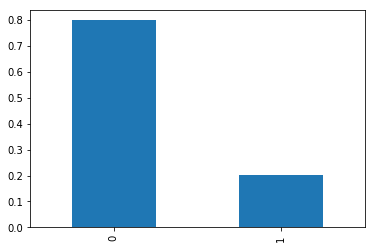

In [11]:
target_train.value_counts(normalize=True).plot(kind='bar')

**Conclusion:** there is class imbalance

### Quality of unadjusted models

In [12]:
from sklearn.metrics import f1_score, roc_auc_score

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345)
    
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
probablities_valid = model.predict_proba(features_valid)[:, 1]

print('F1 =', f1_score(target_valid, predicted_valid))
print('AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

F1 = 0.281021897810219
AUC-ROC = 0.7552634464608805


/usr/local/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


In [14]:
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("max_depth =", depth)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

/usr/local/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


max_depth = 1
  F1 = 0.0
  AUC-ROC = 0.6817792763979506
max_depth = 2
  F1 = 0.47467438494934877
  AUC-ROC = 0.720987840463963
max_depth = 4
  F1 = 0.5054945054945055
  AUC-ROC = 0.7941171543274181
max_depth = 6
  F1 = 0.509493670886076
  AUC-ROC = 0.8202150763626174
max_depth = 8
  F1 = 0.533132530120482
  AUC-ROC = 0.7932505741664687
max_depth = None
  F1 = 0.4688995215311005
  AUC-ROC = 0.6654665521379705


In [15]:
from sklearn.ensemble import RandomForestClassifier

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators=estim)

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("n_estimators =", estim)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

n_estimators = 10
  F1 = 0.4976228209191759
  AUC-ROC = 0.8095701518723615
n_estimators = 20
  F1 = 0.4967741935483871
  AUC-ROC = 0.8242723163428795
n_estimators = 30
  F1 = 0.5239616613418531
  AUC-ROC = 0.8310488513624651
n_estimators = 40
  F1 = 0.5310015898251192
  AUC-ROC = 0.8406048394466071
n_estimators = 50
  F1 = 0.5383411580594679
  AUC-ROC = 0.8418613045305847
n_estimators = 60
  F1 = 0.5429017160686428
  AUC-ROC = 0.8448463609725192
n_estimators = 70
  F1 = 0.5408805031446542
  AUC-ROC = 0.8441214186937637
n_estimators = 80
  F1 = 0.5482866043613708
  AUC-ROC = 0.8445303409665489
n_estimators = 90
  F1 = 0.5474339035769828
  AUC-ROC = 0.8444130708920444
n_estimators = 100
  F1 = 0.5519379844961241
  AUC-ROC = 0.8453931136575471


**Conclusion:** neither of models reaches required quality.

# 3. Fixing imbalance

### Class weight adjustment

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345, class_weight='balanced')
    
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
probablities_valid = model.predict_proba(features_valid)[:, 1]

print('F1 =', f1_score(target_valid, predicted_valid))
print('AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

F1 = 0.4780316344463972
AUC-ROC = 0.7590069509171434


/usr/local/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


In [17]:
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, 
                                   max_depth=depth, class_weight='balanced')

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("max_depth =", depth)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

max_depth = 1
  F1 = 0.4883720930232558
  AUC-ROC = 0.6889632107023411
max_depth = 2
  F1 = 0.5094339622641509
  AUC-ROC = 0.7297549207741653
max_depth = 4
  F1 = 0.5394495412844037
  AUC-ROC = 0.8043767628585874
max_depth = 6
  F1 = 0.5519031141868512
  AUC-ROC = 0.8169124769267321
max_depth = 8
  F1 = 0.5537848605577689
  AUC-ROC = 0.7997872385791132
max_depth = None
  F1 = 0.48088779284833544
  AUC-ROC = 0.6718250269568872


In [18]:
from sklearn.ensemble import RandomForestClassifier

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, 
                                   n_estimators=estim, class_weight='balanced')

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("n_estimators =", estim)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

n_estimators = 10
  F1 = 0.4840764331210191
  AUC-ROC = 0.8084758850083156
n_estimators = 20
  F1 = 0.5023847376788553
  AUC-ROC = 0.8187568153712133
n_estimators = 30
  F1 = 0.502415458937198
  AUC-ROC = 0.8300710930789333
n_estimators = 40
  F1 = 0.5056726094003242
  AUC-ROC = 0.8355028297116679
n_estimators = 50
  F1 = 0.49759229534510424
  AUC-ROC = 0.83919226809462
n_estimators = 60
  F1 = 0.4935483870967742
  AUC-ROC = 0.8419077556639923
n_estimators = 70
  F1 = 0.4959742351046698
  AUC-ROC = 0.8418293217829924
n_estimators = 80
  F1 = 0.5079872204472844
  AUC-ROC = 0.8417950545534294
n_estimators = 90
  F1 = 0.5016077170418007
  AUC-ROC = 0.8428969363573783
n_estimators = 100
  F1 = 0.5016077170418007
  AUC-ROC = 0.8439554130038807


**Conclusion:** взвешивание классов помогает некоторым алгоритмам, но недостаточно weight adjustment helps some of the algorithms but it is not enough

### Upsampling

In [19]:
from sklearn.utils import shuffle

def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
    
    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345)
    
    return features_upsampled, target_upsampled

features_upsampled, target_upsampled = upsample(features_train, target_train, 3)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345)
    
model.fit(features_upsampled, target_upsampled)
predicted_valid = model.predict(features_valid)
probablities_valid = model.predict_proba(features_valid)[:, 1]

print('F1 =', f1_score(target_valid, predicted_valid))
print('AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

F1 = 0.47798742138364775
AUC-ROC = 0.7586383878258434


/usr/local/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


In [21]:
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)

    model.fit(features_upsampled, target_upsampled)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("max_depth =", depth)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

max_depth = 1
  F1 = 0.4883720930232558
  AUC-ROC = 0.6889632107023411
max_depth = 2
  F1 = 0.5094339622641509
  AUC-ROC = 0.7297549207741653
max_depth = 4
  F1 = 0.5419708029197081
  AUC-ROC = 0.8101359419071464
max_depth = 6
  F1 = 0.5628318584070796
  AUC-ROC = 0.8193385967797941
max_depth = 8
  F1 = 0.5741324921135648
  AUC-ROC = 0.8037249240028996
max_depth = None
  F1 = 0.44084682440846823
  AUC-ROC = 0.6469333114023064


In [22]:
from sklearn.ensemble import RandomForestClassifier

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators=estim)

    model.fit(features_upsampled, target_upsampled)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("n_estimators =", estim)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

n_estimators = 10
  F1 = 0.5225988700564972
  AUC-ROC = 0.816583511522927
n_estimators = 20
  F1 = 0.5537190082644629
  AUC-ROC = 0.8293910789456049
n_estimators = 30
  F1 = 0.5401662049861496
  AUC-ROC = 0.8329655317360236
n_estimators = 40
  F1 = 0.5561643835616438
  AUC-ROC = 0.8341024422635256
n_estimators = 50
  F1 = 0.5619834710743802
  AUC-ROC = 0.835489884313833
n_estimators = 60
  F1 = 0.5659340659340659
  AUC-ROC = 0.8371507027066543
n_estimators = 70
  F1 = 0.5737704918032787
  AUC-ROC = 0.8388907164744656
n_estimators = 80
  F1 = 0.5722070844686649
  AUC-ROC = 0.8391755152268339
n_estimators = 90
  F1 = 0.5722070844686649
  AUC-ROC = 0.8375093663760806
n_estimators = 100
  F1 = 0.5710382513661202
  AUC-ROC = 0.8383607166572241


### Downsampling

In [23]:
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat(
        [features_zeros.sample(frac=fraction, random_state=12345)] + [features_ones])
    target_downsampled = pd.concat(
        [target_zeros.sample(frac=fraction, random_state=12345)] + [target_ones])
    
    features_downsampled, target_downsampled = shuffle(
        features_downsampled, target_downsampled, random_state=12345)
    
    return features_downsampled, target_downsampled

features_downsampled, target_downsampled = downsample(features_train, target_train, 0.3)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345)
    
model.fit(features_downsampled, target_downsampled)
predicted_valid = model.predict(features_valid)
probablities_valid = model.predict_proba(features_valid)[:, 1]

print('F1 =', f1_score(target_valid, predicted_valid))
print('AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

F1 = 0.46525096525096526
AUC-ROC = 0.7534069241125549


/usr/local/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


In [25]:
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)

    model.fit(features_downsampled, target_downsampled)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("max_depth =", depth)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

max_depth = 1
  F1 = 0.4688279301745636
  AUC-ROC = 0.680743644571157
max_depth = 2
  F1 = 0.4845024469820556
  AUC-ROC = 0.7243384140212366
max_depth = 4
  F1 = 0.5340599455040873
  AUC-ROC = 0.8052631418632845
max_depth = 6
  F1 = 0.5613079019073569
  AUC-ROC = 0.826347387466418
max_depth = 8
  F1 = 0.5579567779960707
  AUC-ROC = 0.7980388483774088
max_depth = None
  F1 = 0.4904284412032817
  AUC-ROC = 0.6943622030934932


In [26]:
from sklearn.ensemble import RandomForestClassifier

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators=estim)

    model.fit(features_downsampled, target_downsampled)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("n_estimators =", estim)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))

n_estimators = 10
  F1 = 0.5420944558521561
  AUC-ROC = 0.8076161582932788
n_estimators = 20
  F1 = 0.5586136595310907
  AUC-ROC = 0.8232222161302702
n_estimators = 30
  F1 = 0.559841740850643
  AUC-ROC = 0.8303825441209618
n_estimators = 40
  F1 = 0.5584158415841585
  AUC-ROC = 0.8303734061930783
n_estimators = 50
  F1 = 0.5711402623612514
  AUC-ROC = 0.8340605600940598
n_estimators = 60
  F1 = 0.5794768611670019
  AUC-ROC = 0.8362803150757533
n_estimators = 70
  F1 = 0.5768463073852296
  AUC-ROC = 0.8374484468568574
n_estimators = 80
  F1 = 0.5728542914171657
  AUC-ROC = 0.8376296824265463
n_estimators = 90
  F1 = 0.5805805805805806
  AUC-ROC = 0.8387909607617376
n_estimators = 100
  F1 = 0.576271186440678
  AUC-ROC = 0.8387993371956309


### Findings

1) The best model: upsampling + RandomForest(n_estimators=100)

2) F1 and AUC-ROC in general grow simultaneously, but sometimes their maxima don't match (for example, see RandomForest with weight adjustment)

# 4. Model testing

### Training using complete data

In [27]:
features_full_train = pd.concat([features_train, features_valid])
target_full_train = pd.concat([target_train, target_valid])

features_upsampled, target_upsampled = upsample(features_full_train, target_full_train, 3)

model = RandomForestClassifier(random_state=12345, n_estimators=100)
model.fit(features_upsampled, target_upsampled)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=None, max_features='auto', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=12345,
                       verbose=0, warm_start=False)

In [28]:
predicted_test = model.predict(features_test)
probablities_test = model.predict_proba(features_test)[:, 1]

print('F1 =', f1_score(target_test, predicted_test))
print('AUC-ROC =', roc_auc_score(target_test, probablities_test))

F1 = 0.6180371352785146
AUC-ROC = 0.850168737536432
